In [2]:
import dask
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.collections import LineCollection
import matplotlib.axes as maxes
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import os
from windrose import WindroseAxes
from io import BytesIO
import warnings
from datetime import datetime, timedelta
import xarray as xr
import glob
warnings.filterwarnings('ignore')

In [ ]:
lidarn = xr.open_mfdataset(sorted(glob.glob(rf"/qfs/people/gold396/ORACLE/wfip3/nant.lidar.10min.z01.c1/*")))
print(list(lidarn.data_vars)[:10])
print(lidarn.height.min())

In [ ]:
lidara = xr.open_mfdataset(sorted(glob.glob(rf"/qfs/people/gold396/ORACLE/wfip3/asit.lidar.z01.a0/*")))
print(list(lidara.data_vars)[:10])
print(lidara.height.min())

In [ ]:
lidarb = xr.open_mfdataset(sorted(glob.glob(rf"/qfs/people/gold396/ORACLE/wfip3/barg.lidar.z02.a0/*")))
print(list(lidarb.data_vars)[:10])
print(lidarb.height.min())

In [15]:
lidara

<xarray.Dataset> Size: 966MB
Dimensions:                       (time: 1711978, height: 11)
Coordinates:
  * height                        (height) float64 88B 38.0 47.0 ... 167.0 187.0
  * time                          (time) datetime64[ns] 14MB 2024-07-01T00:08...
Data variables: (12/22)
    GPS                           (time) <U18 123MB dask.array<chunksize=(4814,), meta=np.ndarray>
    buoy_bearing                  (time) float64 14MB dask.array<chunksize=(512,), meta=np.ndarray>
    buoy_tilt                     (time) float64 14MB dask.array<chunksize=(482,), meta=np.ndarray>
    air_temperature               (time) float64 14MB dask.array<chunksize=(482,), meta=np.ndarray>
    air_pressure                  (time) float64 14MB dask.array<chunksize=(482,), meta=np.ndarray>
    air_humidity                  (time) float64 14MB dask.array<chunksize=(482,), meta=np.ndarray>
    ...                            ...
    qc_air_humidity               (time) int32 7MB dask.array<chunksize=(963,), meta=np.ndarray>
    qc_surface_wind_speed         (time) int32 7MB dask.array<chunksize=(963,), meta=np.ndarray>
    qc_surface_wind_direction     (time) int32 7MB dask.array<chunksize=(963,), meta=np.ndarray>
    qc_horizontal_wind_speed      (time, height) int32 75MB dask.array<chunksize=(1, 11), meta=np.ndarray>
    qc_horizontal_wind_direction  (time, height) int32 75MB dask.array<chunksize=(1, 11), meta=np.ndarray>
    qc_vertical_wind_speed        (time, height) int32 75MB dask.array<chunksize=(1, 11), meta=np.ndarray>
Attributes: (12/13)
    title:         lidar
    description:   Asit WindCube lidar
    Conventions:   CF-1.6
    featureType:   timeSeries
    institution:   Wind Data Hub
    location_id:   asit
    ...            ...
    data_level:    a0
    datastream:    asit.lidar.z01.a0
    history:       Created by sbx_user1051 at 2025-03-31T23:02:12.127336 usin...
    code_version:  4e34d808448ad25c25fc569a0a488da7904f83da
    z_id:          z01
    inputs:        /tmp/tmp4yfupyo_/wfip3/asit.lidar.z01.00/2024/07/01/asit.l...

In [24]:
# Define datasets to load: (name, glob_pattern, variable, height_level, y_offset, color)
datasets_config = [
    ('Nant Winds', '/qfs/people/gold396/ORACLE/wfip3/nant.lidar.10min.z01.c1/*', 'wd', 100, 1.0, 'blue'),
    ('Nant Rain', '/qfs/people/gold396/ORACLE/wfip3/nant.ld.z01.b1/*', 'rain_intensity', None, 0.5, 'blue'),
    ('Asit Winds', '/qfs/people/gold396/ORACLE/wfip3/asit.lidar.z01.a0/*', 'horizontal_wind_direction', 97, 0.0, 'orange'),
    ('Asit Rain 1', '/qfs/people/gold396/ORACLE/wfip3/asit.ld.z01.b1/*', 'rain_intensity', None, -0.25, 'orange'),
    ('Asit Rain 2', '/qfs/people/gold396/ORACLE/wfip3/asit.ld.z02.b1/*', 'rain_intensity', None, -0.75, 'orange'),
    ('Barg Winds', '/qfs/people/gold396/ORACLE/wfip3/barg.lidar.z02.a0/*', 'wind_direction', 100, -1.0, 'green'),
    ('Barg Rain 1', '/qfs/people/gold396/ORACLE/wfip3/barg.ld.z01.b1/*', 'rain_intensity', None, -1.25, 'green'),
    ('Barg Rain 2', '/qfs/people/gold396/ORACLE/wfip3/barg.ld.z02.b1/*', 'rain_intensity', None, -1.75, 'green'),
]

# Load all datasets efficiently
datasets = {}
for name, pattern, _, _, _, _ in datasets_config:
    try:
        ds = xr.open_mfdataset(sorted(glob.glob(pattern)), combine='by_coords')
        datasets[name] = ds
        print(f"✓ Loaded {name}: {len(ds.time)} time steps")
    except Exception as e:
        print(f"✗ Failed to load {name}: {e}")


✓ Loaded Nant Winds: 24148 time steps
✓ Loaded Nant Rain: 1281227 time steps
✓ Loaded Asit Winds: 1711978 time steps
✓ Loaded Asit Rain 1: 1374314 time steps
✓ Loaded Asit Rain 2: 1297933 time steps
✓ Loaded Barg Winds: 15623 time steps
✓ Loaded Barg Rain 1: 748036 time steps
✓ Loaded Barg Rain 2: 434560 time steps


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lidarn.time, 1 + 0*(lidarn['wd'].sel(height=100).values), label='nant.lidar.10min.z01.c1', color='blue')
ax.plot(nld.time, .5 + 0*(nld['rain_intensity']), color='blue')

ax.plot(lidara.time, 0 + 0*(lidara['horizontal_wind_direction'].sel(height=97).values), label='asit.lidar.z01.a0', color='orange')
ax.plot(ald1.time, -.25 + 0*(ald1['rain_intensity']), color='orange')
ax.plot(ald2.time, -.75 + 0*(ald2['rain_intensity']), color='orange')

ax.plot(lidarb.time, -1 + 0*(lidarb['wind_direction'].sel(height=100).values), label='barg.lidar.z02.a0', color='green')
ax.plot(bld1.time, -1.25 + 0*(bld1['rain_intensity']), color='green')
ax.plot(bld2.time, -1.75 + 0*(bld2['rain_intensity']), color='green')
ax.set_xlabel('Time') 
ax.set_ylabel('Timeline')
positions = [-1.75, -1.25, -1, -.75, -.25, 0, .5, 1]
labels = ['Barg Rain 2', 'Barg Rain 1', 'Barg Winds', 'Asit Rain 2','Asit Rain 1','Asit Winds', 'Nant Rain', 'Nant Winds']
ax.set_yticks(positions, labels)
ax.set_title('Data Timeline over Time for Nant, Asit, and Barg')
ax.legend()
ax.grid()
plt.show()  

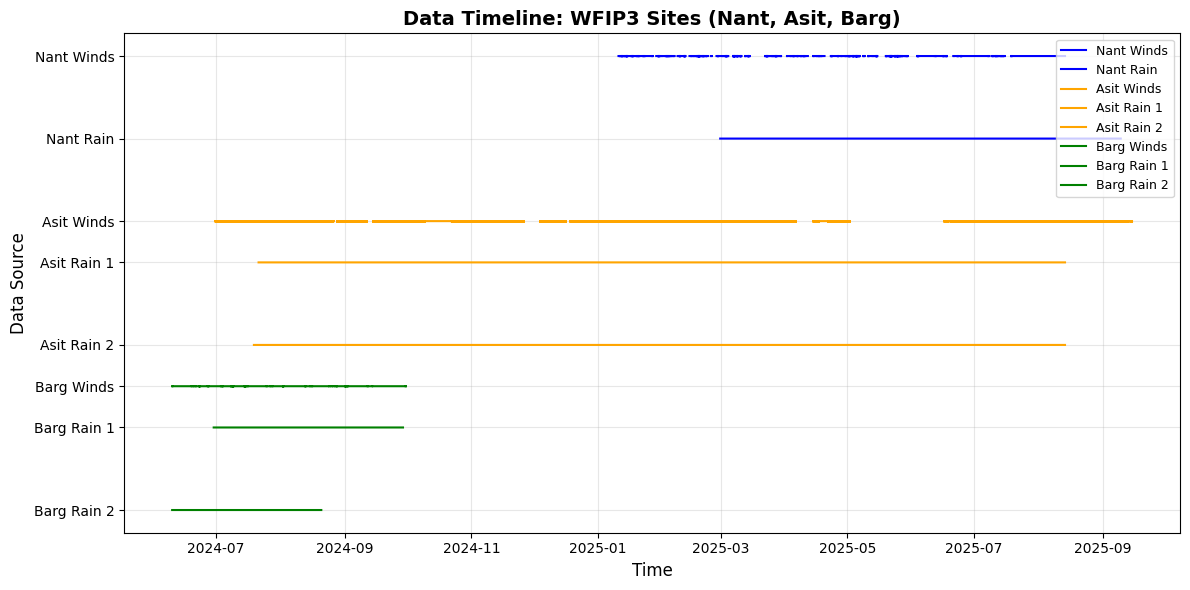

In [35]:
# Efficient refactored plotting using the datasets_config
fig, ax = plt.subplots(figsize=(12, 6))

# Plot all datasets using loop
for label, pattern, var, height, y_offset, color in datasets_config:
    if label not in datasets:
        print(f"Skipping {label}: not loaded")
        continue
    
    ds = datasets[label]
    try:
        if var not in ds.data_vars:
            print(f"  Skipping {var}: not in {label}")
            continue
        
        # Extract variable; select height if specified
        data = ds[var]
        if height is not None and 'height' in data.dims:
            data = data.sel(height=height, method='nearest')
        
        # Plot: y_offset values only mark timeline, time values show when data exists
        valid = np.isfinite(data.values)
        y = np.full(ds.time.size, np.nan, dtype=float)
        y[valid] = y_offset
        ax.plot(ds.time.values, y, label=label, color=color, linewidth=1.5)
        # ax.plot(ds.time, xr.full_like(ds.time, y_offset), label=label, color=color, linewidth=1.5)
    except Exception as e:
        print(f"  Error plotting {label}: {e}")

# Set labels and formatting
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Data Source', fontsize=12)
positions = [row[4] for row in datasets_config]
labels_list = [row[0] for row in datasets_config]
ax.set_yticks(positions, labels_list, fontsize=10)
ax.set_title('Data Timeline: WFIP3 Sites (Nant, Asit, Barg)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

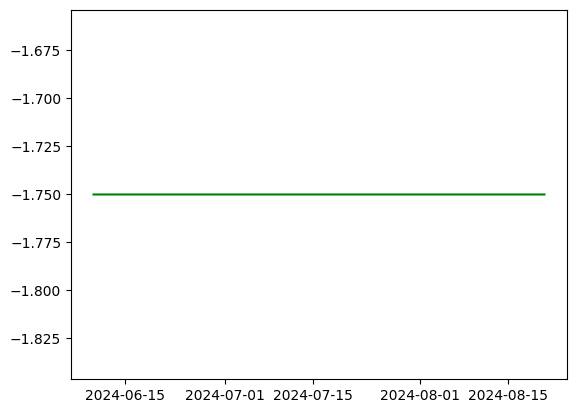

In [34]:
valid = np.isfinite(data.values)
y = np.full(ds.time.size, np.nan, dtype=float)
y[valid] = y_offset
plt.plot(ds.time.values, y, label=label, color=color, linewidth=1.5)

In [18]:
print('lidara vars:', list(lidara.data_vars))
print('surface_wind_direction dims:', lidara['surface_wind_direction'].dims)
print('surface_wind_direction coords:', list(lidara['surface_wind_direction'].coords))
print('dataset coords:', list(lidara.coords))
if 'height' in lidara.coords:
    print('lidara height shape:', lidara['height'].shape)
    print('lidara height sample:', lidara['height'].values[:10] if lidara['height'].ndim == 1 else lidara['height'].values)
if 'height' in lidara['surface_wind_direction'].coords:
    h = lidara['surface_wind_direction']['height']
    print('var height shape:', h.shape)
    print('var height sample:', h.values[:10] if h.ndim == 1 else h.values)

lidara vars: ['GPS', 'buoy_bearing', 'buoy_tilt', 'air_temperature', 'air_pressure', 'air_humidity', 'surface_wind_speed', 'surface_wind_direction', 'horizontal_wind_speed', 'horizontal_wind_direction', 'vertical_wind_speed', 'qc_GPS', 'qc_buoy_bearing', 'qc_buoy_tilt', 'qc_air_temperature', 'qc_air_pressure', 'qc_air_humidity', 'qc_surface_wind_speed', 'qc_surface_wind_direction', 'qc_horizontal_wind_speed', 'qc_horizontal_wind_direction', 'qc_vertical_wind_speed']
surface_wind_direction dims: ('time',)
surface_wind_direction coords: ['time']
dataset coords: ['height', 'time']
lidara height shape: (11,)
lidara height sample: [ 38.  47.  67.  77.  87.  97. 107. 127. 147. 167.]
